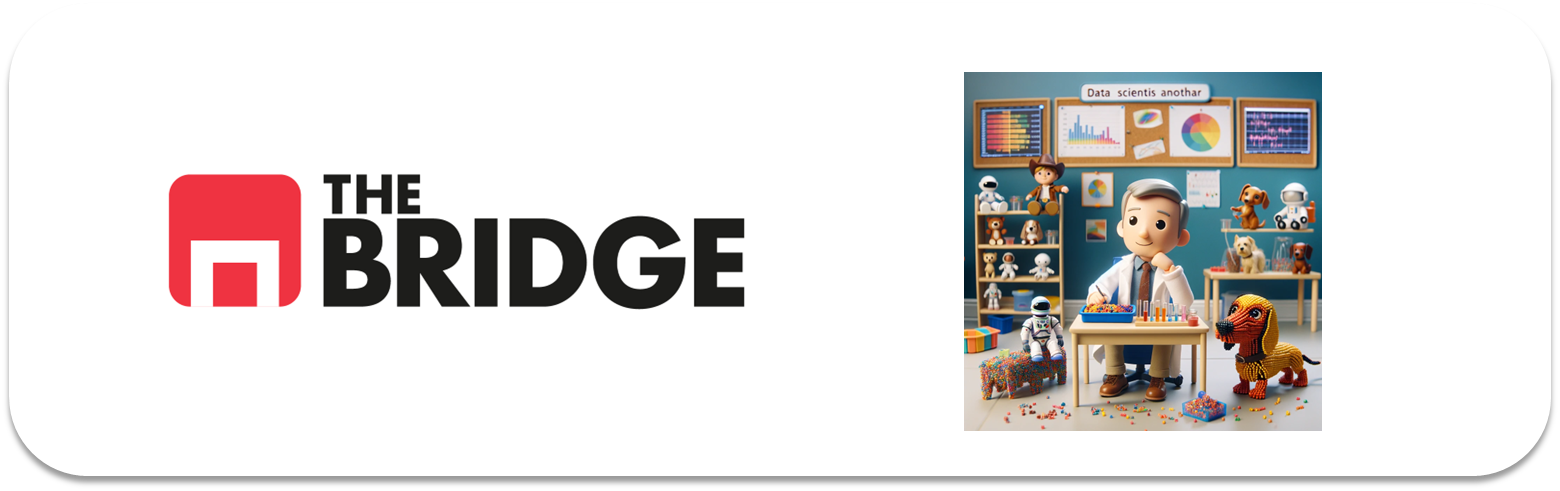

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [8]:
df_titanic = sns.load_dataset("titanic")

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [9]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [ ]:
print(df_titanic.isnull().mean() * 100)

# La columna deck tiene demasiados nulos (203 datos sobre 891 global), la eliminamos.
df_titanic.drop(columns = ["deck", "parch"], inplace = True)

# La columna age la relleno con su mediana para no perder filas.
df_titanic["age"] = df_titanic["age"].fillna(df_titanic["age"].median())

# La columna embarked tiene muy pocos nulos (solo 2 nulos), borramos solo esas filas.
df_titanic.dropna(subset = ["embarked"], inplace = True)


survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [7]:
# Comprobación
print(df_titanic.isnull().mean() * 100)

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| Survived         |Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.|
| pclass           |Indica la "clase" de ticket. |
| sex              |Género del pasajero. |
| age              |Hace referencia a la edad del pasajero al embarcar. |
| sibsp            |Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros). |
| fare             |Monto que hace referencia a la tarifa pagada por el billete. |
| embarked         |Es la incial de la letra de la ciudad donde embarcó la persona. |
| class            |Descripción de la clase del ticket adquirido. |
| who              |Categoría del pasajero (man, woman, child - adulto: hombre o mujer y niños). |
| adult_male       |Booleano de si la persona es un hombre adulto (respuesta de si o no). |
| embark_town      |Puerto en el que se subió al navió (valga la redundancia, donde embarcó) |
| alive            |Booleano de si la persona actualmente esta viva o no |
| alone            |Booleano de si viajaba solo o no |

### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [11]:
ciudades_titanic = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
df_titanic["embarked"] = df_titanic["embarked"].map(ciudades_titanic)

df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,NaN,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,NaN,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,NaN,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,NaN,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,NaN,Third,man,True,NaN,Southampton,no,True


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [ ]:
# Funcion cardinalidad
def cardinalidad(df_in, umbral_categoria, umbral_continua):
    cardinalidad_absoluta = df_in.nunique()
    cardinalidad_porcentaje = (cardinalidad_absoluta / len(df_in)) * 100
    df_categor = pd.DataFrame({
        "Card": cardinalidad_absoluta,
        "% Card": cardinalidad_porcentaje
    })
    
    # Lógica de clasificación
    def clasificar(fila):
        card = fila["Card"]
        porcentaje = fila["% Card"]
        if card == 2:
            return "Binaria"
        if card < umbral_categoria:
            return "Categórica"
        else:
            if porcentaje >= umbral_continua:
                return "Numerica Continua"
            else:
                return "Numerica Discreta"
    
    df_categor["Tipo Sugerido"] = df_categor.apply(clasificar, axis = 1)
    
    return df_categor

In [13]:
# Función para gráficos 
def pinta_distribucion_categoricas(df, columnas_categoricas, relativa = False, mostrar_valores = False):
    num_columnas = len(columnas_categoricas)
    num_filas = (num_columnas // 2) + (num_columnas % 2)

    fig, axes = plt.subplots(num_filas, 2, figsize=(15, 5 * num_filas))
    axes = axes.flatten() 

    for i, col in enumerate(columnas_categoricas):
        ax = axes[i]
        if relativa:
            total = df[col].value_counts().sum()
            serie = df[col].value_counts().apply(lambda x: x / total)
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia Relativa')
        else:
            serie = df[col].value_counts()
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia')

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if mostrar_valores:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    for j in range(i + 1, num_filas * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [15]:
# Determinación de variables 
resultados = cardinalidad(df_titanic, umbral_categoria = 10, umbral_continua = 5.0)
print(resultados)

             Card     % Card      Tipo Sugerido
survived        2   0.224467            Binaria
pclass          3   0.336700         Categórica
sex             2   0.224467            Binaria
age            88   9.876543  Numerica Continua
sibsp           7   0.785634         Categórica
parch           7   0.785634         Categórica
fare          248  27.833895  Numerica Continua
embarked        0   0.000000         Categórica
class           3   0.336700         Categórica
who             3   0.336700         Categórica
adult_male      2   0.224467            Binaria
deck            7   0.785634         Categórica
embark_town     3   0.336700         Categórica
alive           2   0.224467            Binaria
alone           2   0.224467            Binaria


### #2.1 Categóricas

In [19]:
variables_categoricas = [
    "survived","who","class","embarked","alone"
]

# Frecuencias absolutas
for catego in variables_categoricas:
    print(f" Para {catego}")
    print(df_titanic[catego].value_counts())
    print("\n")

 Para survived
survived
0    549
1    342
Name: count, dtype: int64


 Para who
who
man      537
woman    271
child     83
Name: count, dtype: int64


 Para class
class
Third     491
First     216
Second    184
Name: count, dtype: int64


 Para embarked
Series([], Name: count, dtype: int64)


 Para alone
alone
True     537
False    354
Name: count, dtype: int64




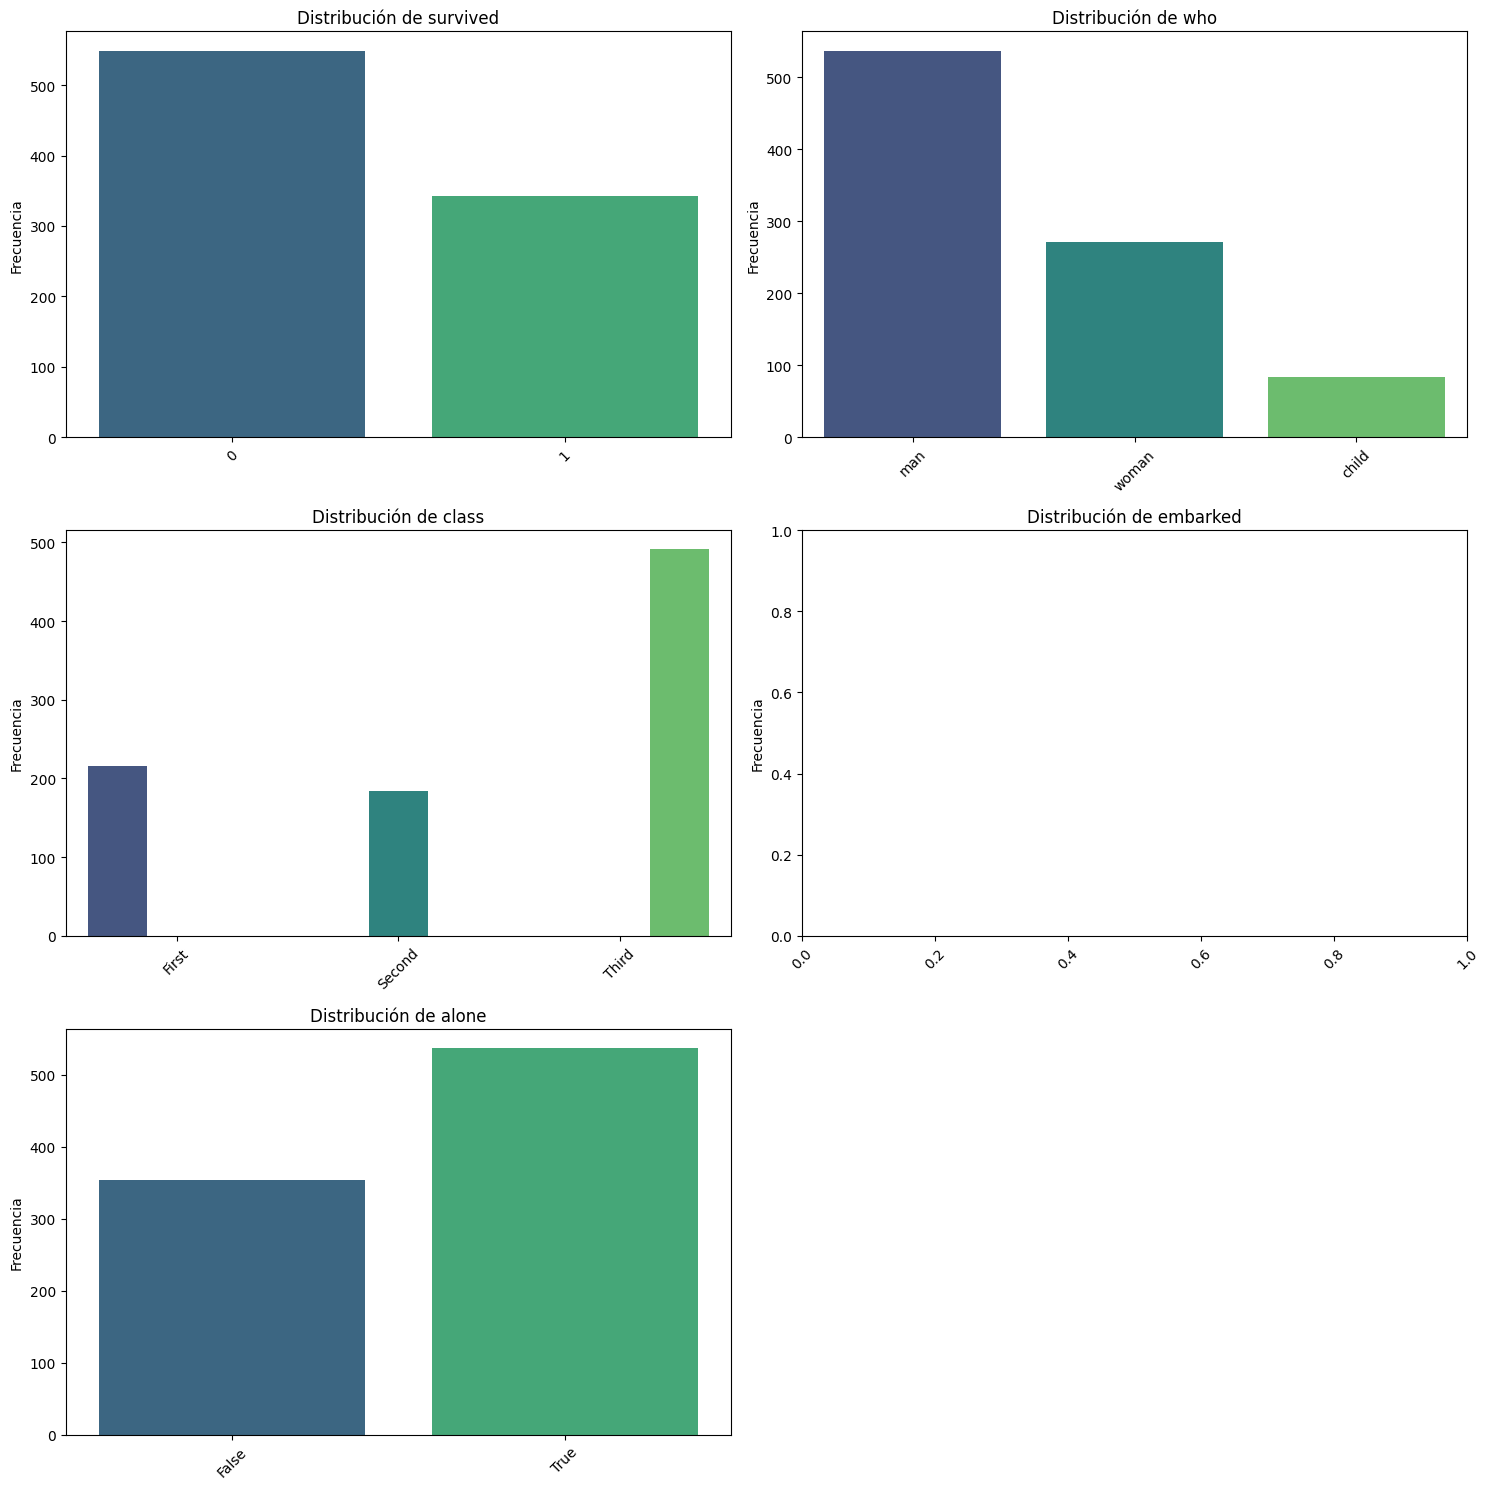

In [20]:
pinta_distribucion_categoricas(df_titanic, variables_categoricas)

## Observaciones
-  La mayoría de los pasajeros no sobrevivió (más del 60%).
- Hay una mayoría de hombres adultos fallecidos, este dato es muy relevante para el análisis de supervivencia (si lo contraponemos con el "mujeres y niños primero" hay coicidencia real de este proceder)
- Existe una correlación visual clara entre la clase y la supervivencia. Aunque la 3ª clase es la más abundante, su tasa de mortalidad es desproporcionadamente alta comparada con la 1ª clase. La clase social fue un factor determinante en la probabilidad de supervivencia, lo que sugiere un sesgo socioeconómico en el acceso a los recursos de evacuación.

### #2.2 Numéricas

In [26]:
def variabilidad(df):
    df_var = df.describe().loc[["std","mean"]].T
    df_var["CV"] = df_var["std"]/df_var["mean"]
    return df_var

In [ ]:
variables_numericas = [
    "age","fare"
]

df_titanic[variables_numericas].describe().T




,count,mean,std,min,25%,50%,75%,max
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [36]:
variabilidad(df_titanic[variables_numericas])

,std,mean,CV
age,14.526497,29.699118,0.489122
fare,49.693429,32.204208,1.543073


In [37]:
def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


def plot_histo_den(df, columns):
    num_cols = len(columns)
    num_rows = num_cols // 2 + num_cols % 2
    fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, ax=axes[i])
            axes[i].set_title(f'Histograma y KDE de {column}')

    # Ocultar ejes vacíos
    for j in range(i + 1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fare'}>]], dtype=object)

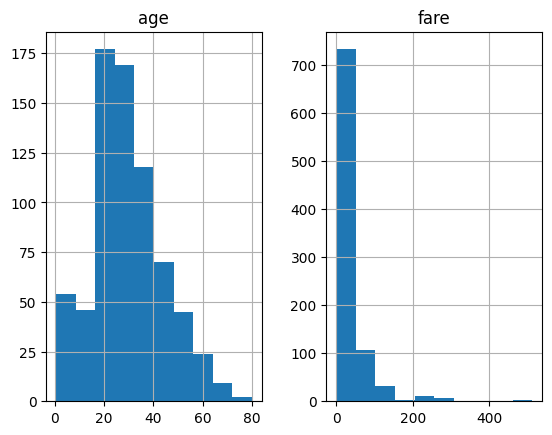

In [38]:
df_titanic[variables_numericas].hist()

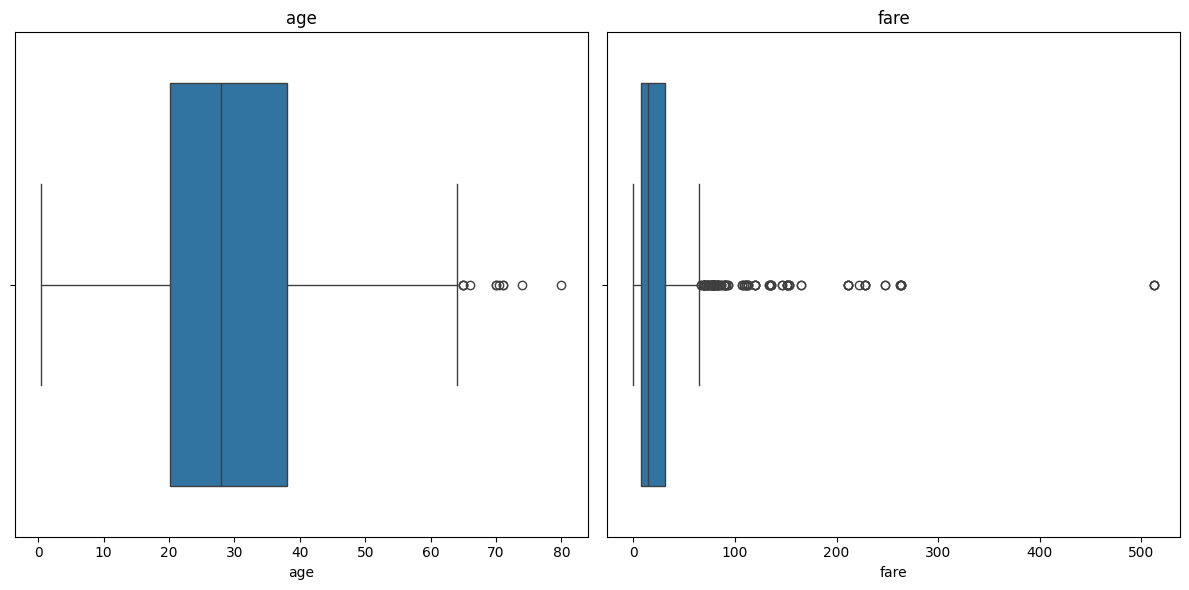

In [43]:
plot_multiple_boxplots(df_titanic, variables_numericas)

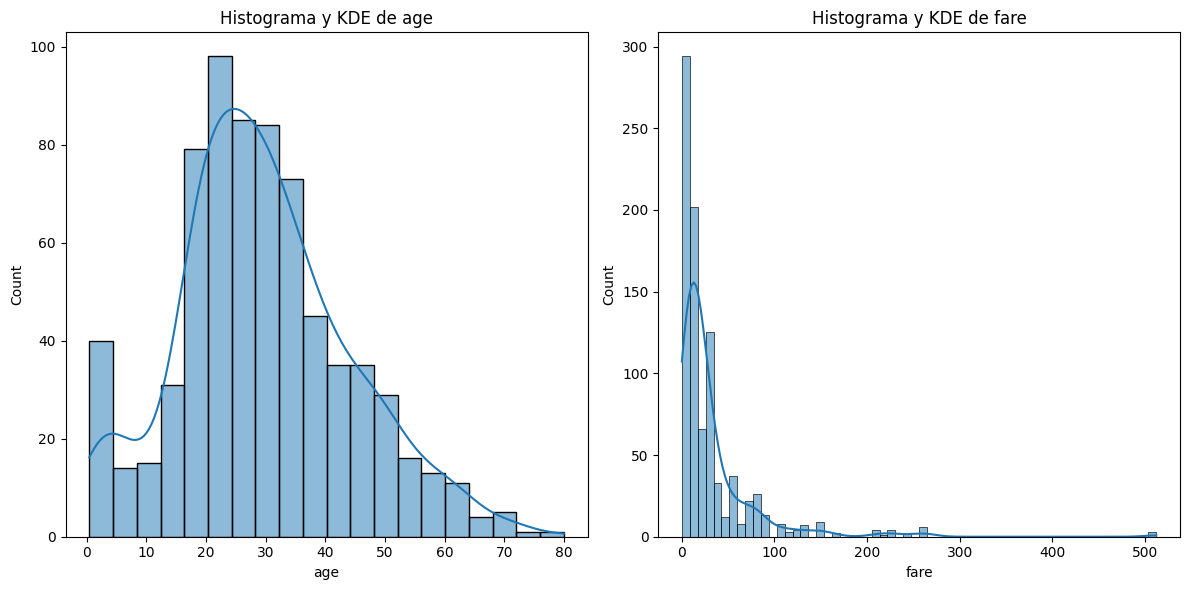

In [42]:
plot_histo_den(df_titanic, variables_numericas)

## Observaciones
- La mayoría de los pasajeros tienen entre 20 y 40 años. 
- Se observa un pequeño repunte en la primera barra (0-5 años), lo que confirma que había un número considerable de niños a bordo (y además concuerda con la peli jeje)
- Pocos pasajeros de "tercera edad" (más de 65-70 años).
- La inmensa mayoría de los pasajeros pagaron las tarifas bajas (entre 0 y 50).
- La barra más alta coincide con el precio de los billetes de 3ª clase.

Outliers (Valores Atípicos): Se ven pequeñas marcas casi invisibles, esto nos indica que exiten pocas personas que pagaron tickets hasta 10 veces mas costosos que la media adquirida

### En temas de supervivencia/ mortalidad
- La clase mas baja fue la mas afectada en cuanto a mortalidad